In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append(r'C:\Chimera\B240_data_analysis\Library\ChimeraGenTools')


import AnalysisHelpers as ah
import MatplotlibPlotters as mp
from fitters import linear

I am imported expfile
I am imported Miscellaneous


In [4]:
freqLUT = np.load('./freqLUT_20251216_data3.npy')
print(freqLUT.shape)
gridShape = freqLUT.shape[:2]

print(gridShape)
print(freqLUT[0,:,0])
print(freqLUT[1,:,0])

(5, 20, 2)
(5, 20)
[104.02786612 103.12439794 102.24135058 101.34059163 100.44805944
  99.56267707  98.65798499  97.76469073  96.8604669   95.96471208
  95.05413266  94.17497033  93.29501634  92.38203096  91.48445436
  90.5749393   89.68641317  88.79077335  87.8815343   86.98846348]
[104.0254228  103.13632008 102.23529035 101.33974446 100.45080557
  99.5663196   98.66160309  97.76421589  96.85967593  95.98110305
  95.07196492  94.17455553  93.30470935  92.38304079  91.49167029
  90.58722863  89.69641497  88.79397795  87.88943865  87.00295934]


Slope: -8.9676(72)e-01
Offset: 1.040345(80)e+02
rounded p = [-0.89676, 104.03453168426567]


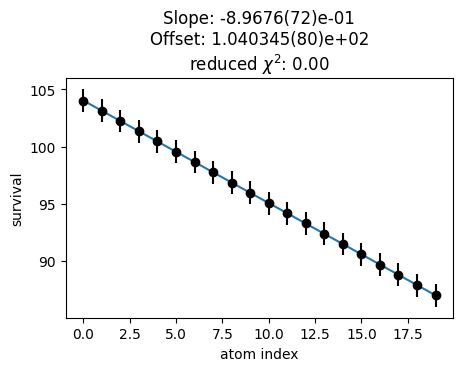

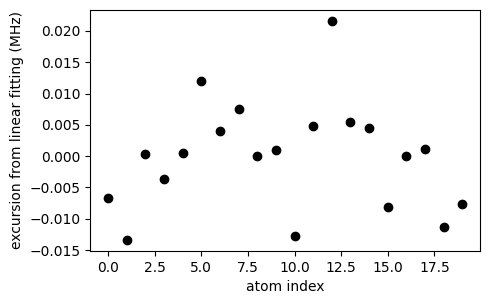

Slope: -8.9623(72)e-01
Offset: 1.040350(80)e+02
rounded p = [-0.89623, 104.03503675788573]


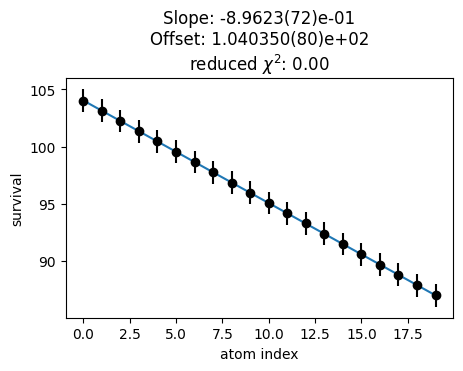

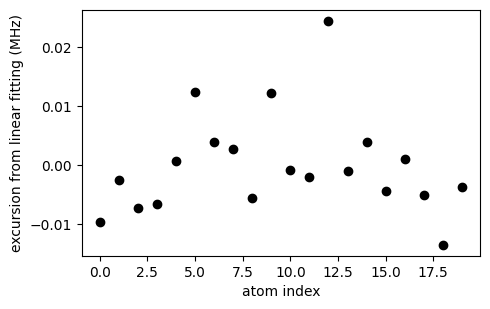

Slope: -8.9671(58)e-01
Offset: 1.040478(65)e+02
rounded p = [-0.89671, 104.04784505287115]


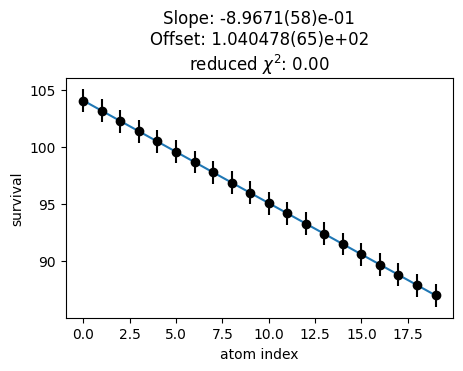

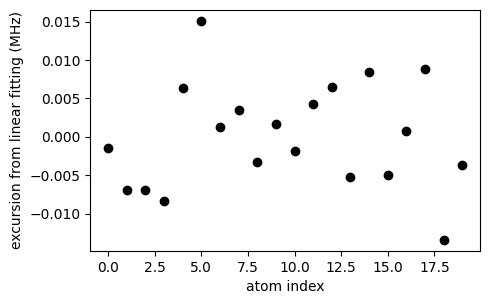

Slope: -8.9635(68)e-01
Offset: 1.040496(75)e+02
rounded p = [-0.89635, 104.04963558029337]


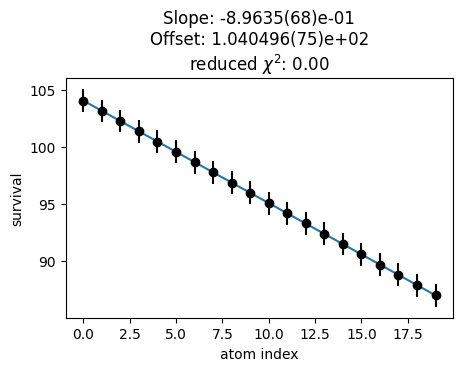

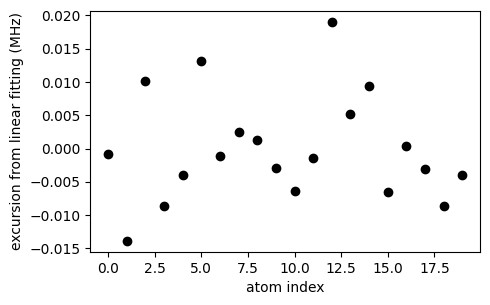

Slope: -8.9677(70)e-01
Offset: 1.040622(77)e+02
rounded p = [-0.89677, 104.06220272634839]


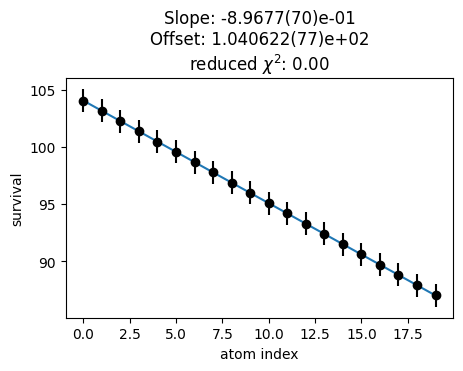

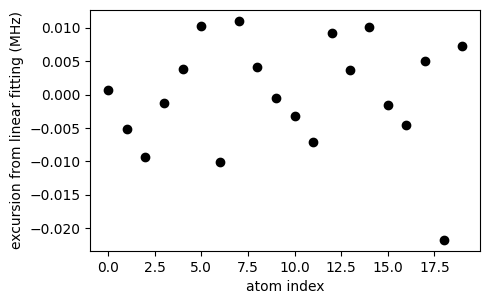

[[[ 6.66387545e-03  0.00000000e+00]
  [ 1.33720601e-02  0.00000000e+00]
  [-3.40579097e-04  0.00000000e+00]
  [ 3.65837232e-03  0.00000000e+00]
  [-5.69435387e-04  0.00000000e+00]
  [-1.19470665e-02  0.00000000e+00]
  [-4.01499337e-03  0.00000000e+00]
  [-7.48072756e-03  0.00000000e+00]
  [-1.69035384e-05  0.00000000e+00]
  [-1.02207919e-03  0.00000000e+00]
  [ 1.27973375e-02  0.00000000e+00]
  [-4.80033156e-03  0.00000000e+00]
  [-2.16063354e-02  0.00000000e+00]
  [-5.38095855e-03  0.00000000e+00]
  [-4.56436463e-03  0.00000000e+00]
  [ 8.19070379e-03  0.00000000e+00]
  [-4.31664404e-05  0.00000000e+00]
  [-1.16334799e-03  0.00000000e+00]
  [ 1.13156986e-02  0.00000000e+00]
  [ 7.62651772e-03  0.00000000e+00]]

 [[ 9.61719999e-03  0.00000000e+00]
  [ 2.48992091e-03  0.00000000e+00]
  [ 7.28964724e-03  0.00000000e+00]
  [ 6.60554035e-03  0.00000000e+00]
  [-6.85567143e-04  0.00000000e+00]
  [-1.24296037e-02  0.00000000e+00]
  [-3.94308612e-03  0.00000000e+00]
  [-2.78588504e-03  0.0000

In [6]:
row,col = gridShape
freqLUT_new = np.zeros_like(freqLUT)
freqLUT_new[:,:,1] = freqLUT[:,:,1]

for idrow in range(row):
    x_grid_idx,x_freq = np.arange(col), freqLUT[idrow,:,0]
    function = linear
    p0 = None
    punc,p,_ = ah.fit_data(x_grid_idx,x_freq, fit_function=function, use_unc=False)

    x,y = x_grid_idx,x_freq
    fig,ax = mp._plotStandard1D(x,y,exp_file=None, fitb=True, fit_function=function,
                                    guess=p0, ignore_zero_unc=True, use_unc=False, plot_guess=False, fit_result_on_title=True, data_name_newline=True, ylim=None)
    ax.set_title(ax.get_title())
    ax.set_xlabel('atom index')
    ax.set_ylabel('survival')
    print(f'rounded p = [{np.round(p[0],5)}, {p[1]}]')
    plt.show()
    p = [np.round(p[0],5), p[1]]

    x,y = x_grid_idx,x_freq-linear.f(x_grid_idx, *p)
    fig,ax = mp._plotStandard1D(x,y,np.zeros_like(y),exp_file=None, fitb=False, fit_function=function,
                                    guess=p0, ignore_zero_unc=True, use_unc=False, plot_guess=False, fit_result_on_title=True, data_name_newline=True, ylim=None)
    ax.set_title(ax.get_title())
    ax.set_xlabel('atom index')
    ax.set_ylabel('excursion from linear fitting (MHz)')
    fig.tight_layout()
    mp.GoldenRatio(fig)
    plt.show()

    freqLUT_new[idrow,:,0] = np.round(linear.f(x_grid_idx, *p), 5)

# freqLUT_new[0,:,1] = np.round(freqLUT[0,:,1].mean(), 5)
# freqLUT_new[0,:,1] = np.repeat(freqLUT[0,0,1], gridShape[0])

print(freqLUT_new-freqLUT)
print(freqLUT_new.shape)
# np.save('./freqLUT_uniform_spacing.npy', freqLUT_new)
# freqLUT = freqLUT.reshape(*pts_Marana_SLM.shape)
# freqLUT.shape